# Feature Ablation Experiment
This notebook tests the best-performing model (Tuned Random Forest) by systematically removing specific features. The goal is to observe the impact of individual features on the overall predictive performance (measured in ROC-AUC) and confirm the hypothesis regarding data leakage and statistical noise.


## 1. Library Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')


## 2. Load Data and Define Features

In [2]:
print("Loading data...")
df = pd.read_csv('data/loan_data.csv')
y = df['loan_status'].astype(int)
X_all = df.drop(columns=['loan_status'])

# Master lists of features
all_num = ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score']
all_ord = ['person_education']
all_nom = ['person_gender', 'person_home_ownership', 'loan_intent', 'previous_loan_defaults_on_file']


Loading data...


## 3. Evaluation Function
This function dynamically builds the Preprocessing + SMOTE + Random Forest pipeline, tracks the training time, and calculates the ROC-AUC score.


In [3]:
def train_evaluate(drop_cols, description):
    print(f"\n--- Running Experiment: {description} ---")
    if drop_cols:
        print(f"Dropping features: {drop_cols}")
    
    # Drop specified columns
    X = X_all.drop(columns=drop_cols)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    # Filter feature lists
    num_f = [c for c in all_num if c not in drop_cols]
    ord_f = [c for c in all_ord if c not in drop_cols]
    nom_f = [c for c in all_nom if c not in drop_cols]
    
    transformers = []
    if num_f:
        transformers.append(('num', ImbPipeline([('imp', SimpleImputer(strategy='median')), ('scl', StandardScaler())]), num_f))
    if ord_f:
        transformers.append(('ord', ImbPipeline([('imp', SimpleImputer(strategy='most_frequent')), ('enc', OrdinalEncoder(categories=[['High School', 'Associate', 'Bachelor', 'Master', 'Doctorate']], handle_unknown='use_encoded_value', unknown_value=-1))]), ord_f))
    if nom_f:
        transformers.append(('nom', ImbPipeline([('imp', SimpleImputer(strategy='most_frequent')), ('enc', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))]), nom_f))
        
    preprocessor = ColumnTransformer(transformers, remainder='drop')
    
    # Tuned Random Forest Hyperparameters
    rf = RandomForestClassifier(n_estimators=200, max_depth=20, min_samples_split=2, random_state=42, n_jobs=-1)
    
    pipe = ImbPipeline([
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('classifier', rf)
    ])
    
    start_time = time.time()
    pipe.fit(X_train, y_train)
    end_time = time.time()
    training_time = end_time - start_time
    
    y_prob = pipe.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    
    print(f"ROC-AUC Score: {auc:.4f} | Training Time: {training_time:.2f}s")
    return auc, training_time


## 4. Run Ablation Experiments

In [4]:
results = {}

results["Baseline (All 13 Features)"] = train_evaluate([], "Baseline (All 13 Features)")
results["Dropped Gender (Noise)"] = train_evaluate(['person_gender'], "Dropped Weak Feature")
results["Dropped Gender & Intent"] = train_evaluate(['person_gender', 'loan_intent'], "Dropped Multiple Weak Features")
results["Dropped Previous Defaults"] = train_evaluate(['previous_loan_defaults_on_file'], "Dropped Dominant Feature")



--- Running Experiment: Baseline (All 13 Features) ---


ROC-AUC Score: 0.9735 | Training Time: 6.78s

--- Running Experiment: Dropped Weak Feature ---
Dropping features: ['person_gender']


ROC-AUC Score: 0.9744 | Training Time: 2.12s

--- Running Experiment: Dropped Multiple Weak Features ---
Dropping features: ['person_gender', 'loan_intent']


ROC-AUC Score: 0.9696 | Training Time: 2.52s

--- Running Experiment: Dropped Dominant Feature ---
Dropping features: ['previous_loan_defaults_on_file']


ROC-AUC Score: 0.9232 | Training Time: 2.39s


## 5. Visualizing the Results

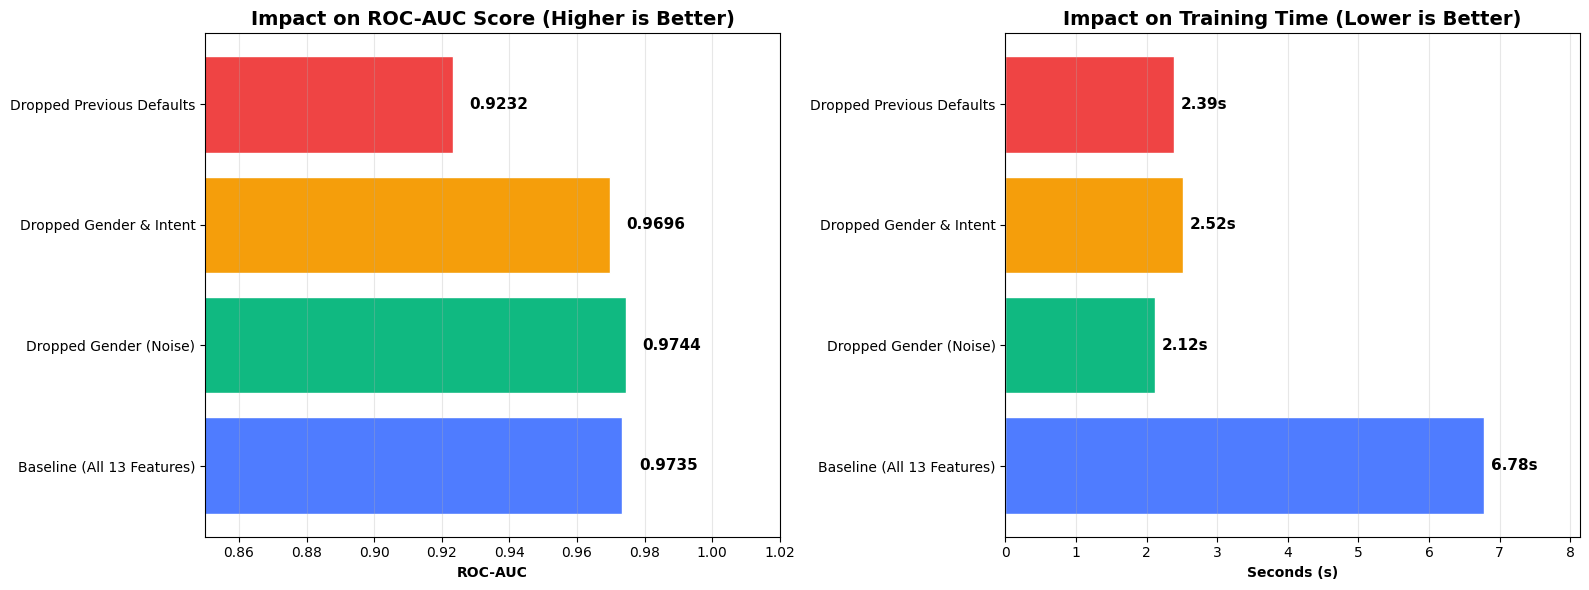

In [5]:
# Create side-by-side bar charts for ROC-AUC and Training Time
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

names = list(results.keys())
scores = [val[0] for val in results.values()]
times = [val[1] for val in results.values()]
colors = ['#4f7cff', '#10b981', '#f59e0b', '#ef4444']

# --- Chart 1: ROC-AUC ---
bars1 = ax1.barh(names, scores, color=colors, edgecolor='white', linewidth=1)
for b in bars1:
    ax1.text(b.get_width() + 0.005, b.get_y() + b.get_height() / 2, 
            f'{b.get_width():.4f}', va='center', fontweight='bold', fontsize=11)
ax1.set_xlim(0.85, 1.02)
ax1.set_title('Impact on ROC-AUC Score (Higher is Better)', fontweight='bold', fontsize=14)
ax1.set_xlabel('ROC-AUC', fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# --- Chart 2: Training Time ---
bars2 = ax2.barh(names, times, color=colors, edgecolor='white', linewidth=1)
for b in bars2:
    ax2.text(b.get_width() + 0.1, b.get_y() + b.get_height() / 2, 
            f'{b.get_width():.2f}s', va='center', fontweight='bold', fontsize=11)
ax2.set_xlim(0, max(times) * 1.2)
ax2.set_title('Impact on Training Time (Lower is Better)', fontweight='bold', fontsize=14)
ax2.set_xlabel('Seconds (s)', fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('charts/ablation_time_results.png')
plt.show()
